# Pendulum Data Preprocessing

Distilled workflow to get corrected data ready for smoothing/analysis.

**Key steps:**
1. Load tracking and field data
2. Preprocess (NaN handling, angle unwrapping)
3. Synchronize and interpolate to 2000 Hz
4. Apply drift correction (time-scaling)

**Output:** `theta_field_trim`, `theta_trk_trim`, `omega_trk_trim`, `alpha_trk_trim`, `mag_field_trim`, `t_trim`

In [1]:
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.stats import linregress
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# Configuration
TRACK_FILE = 'chirp-data/unlube3-1.csv'
FIELD_FILE = 'chirp3-unlube.csv'
B_START = 1529
B_END = 6521
FS_NEW = 2000  # Hz
T_START = 0
T_END = 5
TRIM_END = 6521  # Final length after resampling

## Step 1: Load and Preprocess Tracking Data

In [2]:
# Load tracking data (CSV has 2 header rows)
track_tbl = pd.read_csv(TRACK_FILE, header=1)

t_trk = track_tbl['t'].values
theta_trk = track_tbl['θ'].values / 180 * np.pi  # Convert to radians (already unwrapped)
omega_trk = track_tbl['ω'].values / 180 * np.pi  # Convert to rad/s

# Handle NaN values (backward fill then forward fill)
if np.isnan(omega_trk).sum() > 0:
    omega_series = pd.Series(omega_trk)
    omega_trk = omega_series.bfill().ffill().values

if np.isnan(theta_trk).sum() > 0:
    theta_series = pd.Series(theta_trk)
    theta_trk = theta_series.bfill().ffill().values

print(f"Loaded {len(t_trk)} tracking samples")
print(f"Time range: [{t_trk[0]:.3f}, {t_trk[-1]:.3f}] s")
print(f"Theta range: [{np.min(theta_trk):.2f}, {np.max(theta_trk):.2f}] rad")

Loaded 10070 tracking samples
Time range: [0.000, 5.035] s
Theta range: [-95.44, 121.45] rad


## Step 2: Load and Preprocess Field Data

In [3]:
# Load field data (skip 6 header rows, semicolon-separated)
field_tbl = pd.read_csv(FIELD_FILE, skiprows=6, sep=';')

idx = field_tbl['Index'].values
t_field = idx * 1e-3  # Convert ms to seconds
t_field = t_field[B_START:B_END]  # Trim to relevant window

Bx = field_tbl['Bx[mT]'].values[B_START:B_END]
By = field_tbl['By[mT]'].values[B_START:B_END]
Bz = field_tbl['Bz[mT]'].values[B_START:B_END]

# Compute field angle (wrapped to [-π, π])
theta_field_wrapped = np.arctan2(Bz, By)

# Unwrap field angle to make it continuous (removes discontinuities at ±π)
theta_field = np.unwrap(theta_field_wrapped)

mag_field = np.linalg.norm([By, Bz], axis=0)

print(f"Loaded {len(t_field)} field samples")
print(f"Time range: [{t_field[0]:.3f}, {t_field[-1]:.3f}] s")
print(f"Field angle range: [{np.min(theta_field):.2f}, {np.max(theta_field):.2f}] rad")

Loaded 4992 field samples
Time range: [1.530, 6.521] s
Field angle range: [-95.58, 120.73] rad


## Step 3: Synchronize and Interpolate to 2000 Hz

In [4]:
# Create uniform time grid at 2000 Hz
t_new = np.arange(T_START, T_END + 1/FS_NEW, 1/FS_NEW)

# Offset field time to start at zero
t_field_offset = t_field - t_field[0]

# Interpolate all signals to 2000 Hz using linear interpolation
theta_field_spline = interp1d(t_field_offset, theta_field, kind='linear',
                              bounds_error=False, fill_value='extrapolate')(t_new)
theta_field_wrapped_spline = interp1d(t_field_offset, theta_field_wrapped, kind='linear',
                                      bounds_error=False, fill_value='extrapolate')(t_new)
mag_field_spline = interp1d(t_field_offset, mag_field, kind='linear',
                            bounds_error=False, fill_value='extrapolate')(t_new)
omega_trk_spline = interp1d(t_trk, omega_trk, kind='linear',
                            bounds_error=False, fill_value='extrapolate')(t_new)
theta_trk_spline = interp1d(t_trk, theta_trk, kind='linear',
                            bounds_error=False, fill_value='extrapolate')(t_new)

# Compute angular acceleration
alpha_trk_spline = np.gradient(omega_trk_spline, 1/FS_NEW)

# Trim to specified length
theta_field_trim = theta_field_spline[:TRIM_END]
theta_field_wrapped_trim = theta_field_wrapped_spline[:TRIM_END]
mag_field_trim = mag_field_spline[:TRIM_END]
theta_trk_trim = theta_trk_spline[:TRIM_END]
theta_trk_wrapped_trim = np.arctan2(np.sin(theta_trk_spline[:TRIM_END]), np.cos(theta_trk_spline[:TRIM_END]))
omega_trk_trim = omega_trk_spline[:TRIM_END]
alpha_trk_trim = alpha_trk_spline[:TRIM_END]
t_trim = t_new[:TRIM_END]

print(f"Resampled to {FS_NEW} Hz")
print(f"Final length: {len(t_trim)} samples ({len(t_trim)/FS_NEW:.3f} seconds)")
print(f"Time range: [0, {t_trim[-1]:.4f}] s")

Resampled to 2000 Hz
Final length: 6521 samples (3.260 seconds)
Time range: [0, 3.2600] s


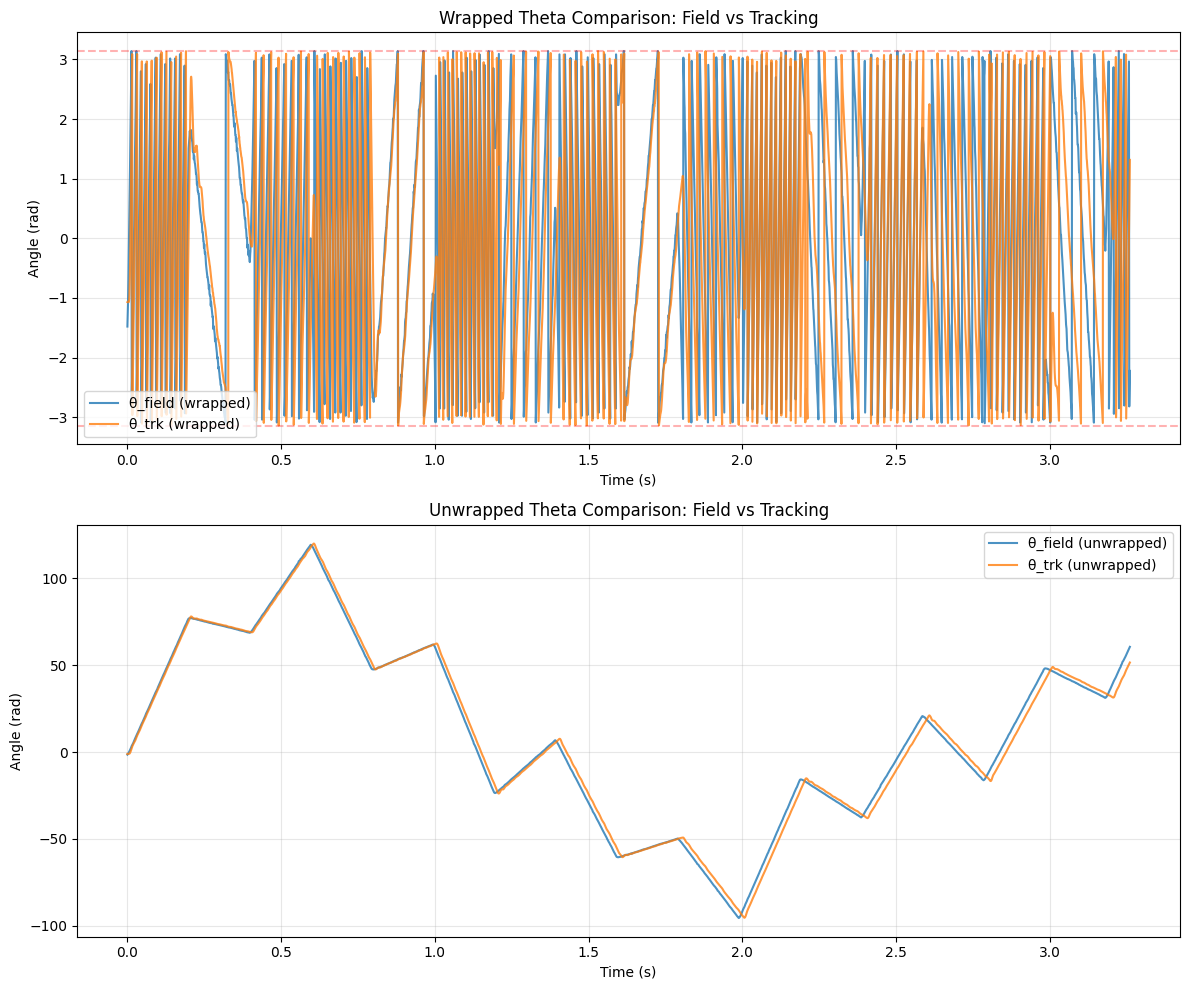

In [5]:
# Plot overlay of wrapped and unwrapped theta values
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Top plot: Wrapped versions
axes[0].plot(t_trim, theta_field_wrapped_trim, label='θ_field (wrapped)', linewidth=1.5, alpha=0.8)
axes[0].plot(t_trim, theta_trk_wrapped_trim, label='θ_trk (wrapped)', linewidth=1.5, alpha=0.8)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Angle (rad)')
axes[0].set_title('Wrapped Theta Comparison: Field vs Tracking')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=np.pi, color='r', linestyle='--', alpha=0.3, label='±π')
axes[0].axhline(y=-np.pi, color='r', linestyle='--', alpha=0.3)

# Bottom plot: Unwrapped versions
axes[1].plot(t_trim, theta_field_trim, label='θ_field (unwrapped)', linewidth=1.5, alpha=0.8)
axes[1].plot(t_trim, theta_trk_trim, label='θ_trk (unwrapped)', linewidth=1.5, alpha=0.8)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Angle (rad)')
axes[1].set_title('Unwrapped Theta Comparison: Field vs Tracking')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# Analyze RELATIVE clock drift between the two data sources
# Note: Internal drift checks don't make sense because:
# - Tracking timestamps use its own clock (will always appear uniform to itself)
# - Field timestamps are synthetic (computed from index, uniform by construction)
# So we need to compare the clocks RELATIVE to each other via phase difference

print("="*70)
print("RELATIVE CLOCK DRIFT ANALYSIS")
print("="*70)
print("\nNote: Internal drift checks are meaningless because:")
print("  - Tracking: Uses its own clock for timestamps (always uniform to itself)")
print("  - Field: Synthetic time from index (uniform by construction)")
print("  → Need to compare clocks RELATIVE to each other\n")

# After synchronization, compute phase difference
phase_diff = theta_field_trim - theta_trk_trim

# Fit linear trend to phase difference (growing phase = clock rate mismatch)
slope_phase, intercept_phase, r_phase, p_phase, _ = linregress(t_trim, phase_diff)

print("1. PHASE DIFFERENCE ANALYSIS (after synchronization)")
print("-" * 70)
print(f"  Phase difference slope: {slope_phase:.6f} rad/s")
print(f"  Phase difference intercept: {intercept_phase:.4f} rad")
print(f"  R²: {r_phase**2:.4f}")
print(f"  Total phase drift over {t_trim[-1]:.3f}s: {slope_phase * t_trim[-1]:.4f} rad ({slope_phase * t_trim[-1] * 180/np.pi:.2f}°)")

# Estimate clock rate mismatch from phase drift
# If phase_diff = slope * t, then one clock is running faster by: slope / omega_avg
omega_avg = np.mean(np.abs(omega_trk_trim))
clock_rate_error = slope_phase / omega_avg if omega_avg > 0 else 0

print(f"\n2. ESTIMATED CLOCK RATE MISMATCH")
print("-" * 70)
print(f"  Average angular velocity: {omega_avg:.2f} rad/s")
print(f"  Estimated clock rate error: {clock_rate_error*100:.4f}%")
print(f"  Clock rate factor: {1 + clock_rate_error:.8f}")

if abs(clock_rate_error) > 0.0001:
    print(f"\n  ⚠ CLOCK RATE MISMATCH DETECTED")
    print(f"     One clock is running {abs(clock_rate_error)*100:.4f}% {'faster' if clock_rate_error > 0 else 'slower'}")
    print(f"     This causes phase to drift by {slope_phase:.6f} rad/s")
    print(f"     Over {t_trim[-1]:.3f}s, this accumulates to {slope_phase * t_trim[-1]:.4f} rad")
else:
    print(f"\n  ✓ Clock rates appear well-matched (error < 0.01%)")

# Check if phase difference is growing linearly (indicates rate mismatch)
if abs(slope_phase) > 0.01:
    print(f"\n3. RECOMMENDATION")
    print("-" * 70)
    print(f"  Apply time-scaling correction:")
    print(f"    - Scale one clock by factor: {1 - clock_rate_error:.8f}")
    print(f"    - This should remove the linear phase drift")

RELATIVE CLOCK DRIFT ANALYSIS

Note: Internal drift checks are meaningless because:
  - Tracking: Uses its own clock for timestamps (always uniform to itself)
  - Field: Synthetic time from index (uniform by construction)
  → Need to compare clocks RELATIVE to each other

1. PHASE DIFFERENCE ANALYSIS (after synchronization)
----------------------------------------------------------------------
  Phase difference slope: 1.030183 rad/s
  Phase difference intercept: -1.6446 rad
  R²: 0.0612
  Total phase drift over 3.260s: 3.3584 rad (192.42°)

2. ESTIMATED CLOCK RATE MISMATCH
----------------------------------------------------------------------
  Average angular velocity: 237.75 rad/s
  Estimated clock rate error: 0.4333%
  Clock rate factor: 1.00433305

  ⚠ CLOCK RATE MISMATCH DETECTED
     One clock is running 0.4333% faster
     This causes phase to drift by 1.030183 rad/s
     Over 3.260s, this accumulates to 3.3584 rad

3. RECOMMENDATION
--------------------------------------------

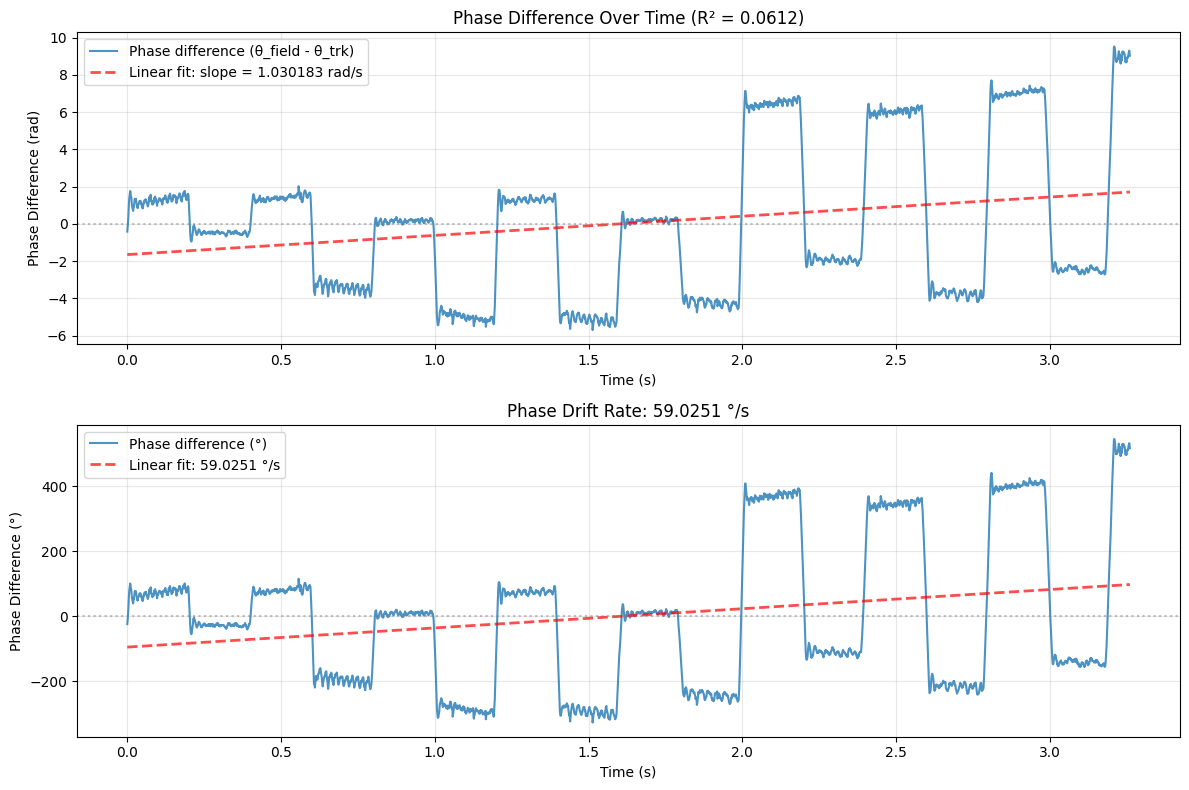

In [7]:
# Visualize phase difference and clock drift
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Top plot: Phase difference over time
axes[0].plot(t_trim, phase_diff, linewidth=1.5, alpha=0.8, label='Phase difference (θ_field - θ_trk)')
if abs(slope_phase) > 0.001:
    # Fit line
    fit_line = intercept_phase + slope_phase * t_trim
    axes[0].plot(t_trim, fit_line, 'r--', linewidth=2, alpha=0.7, 
                label=f'Linear fit: slope = {slope_phase:.6f} rad/s')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Phase Difference (rad)')
axes[0].set_title(f'Phase Difference Over Time (R² = {r_phase**2:.4f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='gray', linestyle=':', alpha=0.5)

# Bottom plot: Phase difference in degrees
phase_diff_deg = phase_diff * 180 / np.pi
fit_line_deg = (intercept_phase + slope_phase * t_trim) * 180 / np.pi
axes[1].plot(t_trim, phase_diff_deg, linewidth=1.5, alpha=0.8, label='Phase difference (°)')
if abs(slope_phase) > 0.001:
    axes[1].plot(t_trim, fit_line_deg, 'r--', linewidth=2, alpha=0.7,
                label=f'Linear fit: {slope_phase*180/np.pi:.4f} °/s')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Phase Difference (°)')
axes[1].set_title(f'Phase Drift Rate: {slope_phase*180/np.pi:.4f} °/s')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

## Analyze Phase Difference Normalized by Field Omega

Since phase difference should correlate with omega, analyze phase_diff / omega_field for drift.

In [8]:
# Compute omega_field from theta_field
omega_field_trim = np.gradient(theta_field_trim, t_trim)

# Compute phase difference normalized by omega_field
# This should be more stable if phase difference correlates with omega
# Avoid division by zero by masking out small omega values
omega_threshold = 1e-3  # rad/s - minimum omega to avoid division issues
valid_mask = np.abs(omega_field_trim) > omega_threshold

phase_diff_normalized = np.zeros_like(phase_diff)
phase_diff_normalized[valid_mask] = phase_diff[valid_mask] / omega_field_trim[valid_mask]
phase_diff_normalized[~valid_mask] = np.nan

# Smooth the normalized phase difference to reduce outliers
from scipy.ndimage import gaussian_filter1d
sigma_smooth_norm = 5.0  # Gaussian smoothing sigma (in samples)
phase_diff_normalized_smooth = phase_diff_normalized.copy()
phase_diff_normalized_smooth[valid_mask] = gaussian_filter1d(
    phase_diff_normalized[valid_mask], sigma=sigma_smooth_norm)

# Fit linear trend to smoothed normalized phase difference to detect drift
valid_indices = np.where(valid_mask)[0]
if len(valid_indices) > 0:
    slope_norm, intercept_norm, r_norm, p_norm, _ = linregress(
        t_trim[valid_indices], phase_diff_normalized_smooth[valid_indices])
    # Also fit to raw for comparison
    slope_norm_raw, intercept_norm_raw, r_norm_raw, _, _ = linregress(
        t_trim[valid_indices], phase_diff_normalized[valid_indices])
else:
    slope_norm = intercept_norm = r_norm = p_norm = np.nan
    slope_norm_raw = intercept_norm_raw = r_norm_raw = np.nan

print("="*70)
print("PHASE DIFFERENCE NORMALIZED BY FIELD OMEGA")
print("="*70)
print(f"\nComputed: phase_diff / omega_field")
print(f"  Valid points (|omega_field| > {omega_threshold}): {np.sum(valid_mask)} / {len(t_trim)} ({np.sum(valid_mask)/len(t_trim)*100:.2f}%)")
print(f"  Invalid points (near zero omega): {np.sum(~valid_mask)} ({np.sum(~valid_mask)/len(t_trim)*100:.2f}%)")

if len(valid_indices) > 0:
    print(f"\nNormalized phase difference statistics:")
    print(f"  Mean: {np.nanmean(phase_diff_normalized):.6f}")
    print(f"  Std: {np.nanstd(phase_diff_normalized):.6f}")
    print(f"  Min: {np.nanmin(phase_diff_normalized):.6f}")
    print(f"  Max: {np.nanmax(phase_diff_normalized):.6f}")
    
    print(f"\nDrift analysis (linear fit to smoothed normalized phase difference):")
    print(f"  Smoothing: Gaussian filter, σ = {sigma_smooth_norm} samples")
    print(f"  Slope (smoothed): {slope_norm:.6f} s⁻¹")
    print(f"  Intercept (smoothed): {intercept_norm:.6f}")
    print(f"  R² (smoothed): {r_norm**2:.4f}")
    print(f"  Total drift over {t_trim[-1]:.3f}s: {slope_norm * t_trim[-1]:.6f}")
    
    if len(valid_indices) > 0 and not np.isnan(slope_norm_raw):
        print(f"\n  Comparison (raw, no smoothing):")
        print(f"    Slope (raw): {slope_norm_raw:.6f} s⁻¹")
        print(f"    R² (raw): {r_norm_raw**2:.4f}")
    
    if abs(slope_norm) > 0.001:
        print(f"\n  ⚠ DRIFT DETECTED in normalized phase difference")
        print(f"     Slope = {slope_norm:.6f} s⁻¹ indicates systematic drift")
    else:
        print(f"\n  ✓ No significant drift detected in normalized phase difference")
else:
    print("\n  ⚠ No valid points for analysis (omega_field too small)")

PHASE DIFFERENCE NORMALIZED BY FIELD OMEGA

Computed: phase_diff / omega_field
  Valid points (|omega_field| > 0.001): 6441 / 6521 (98.77%)
  Invalid points (near zero omega): 80 (1.23%)

Normalized phase difference statistics:
  Mean: 0.013240
  Std: 0.041961
  Min: -0.973287
  Max: 2.017328

Drift analysis (linear fit to smoothed normalized phase difference):
  Smoothing: Gaussian filter, σ = 5.0 samples
  Slope (smoothed): 0.006072 s⁻¹
  Intercept (smoothed): 0.003317
  R² (smoothed): 0.2332
  Total drift over 3.260s: 0.019796

  Comparison (raw, no smoothing):
    Slope (raw): 0.006072 s⁻¹
    R² (raw): 0.0185

  ⚠ DRIFT DETECTED in normalized phase difference
     Slope = 0.006072 s⁻¹ indicates systematic drift


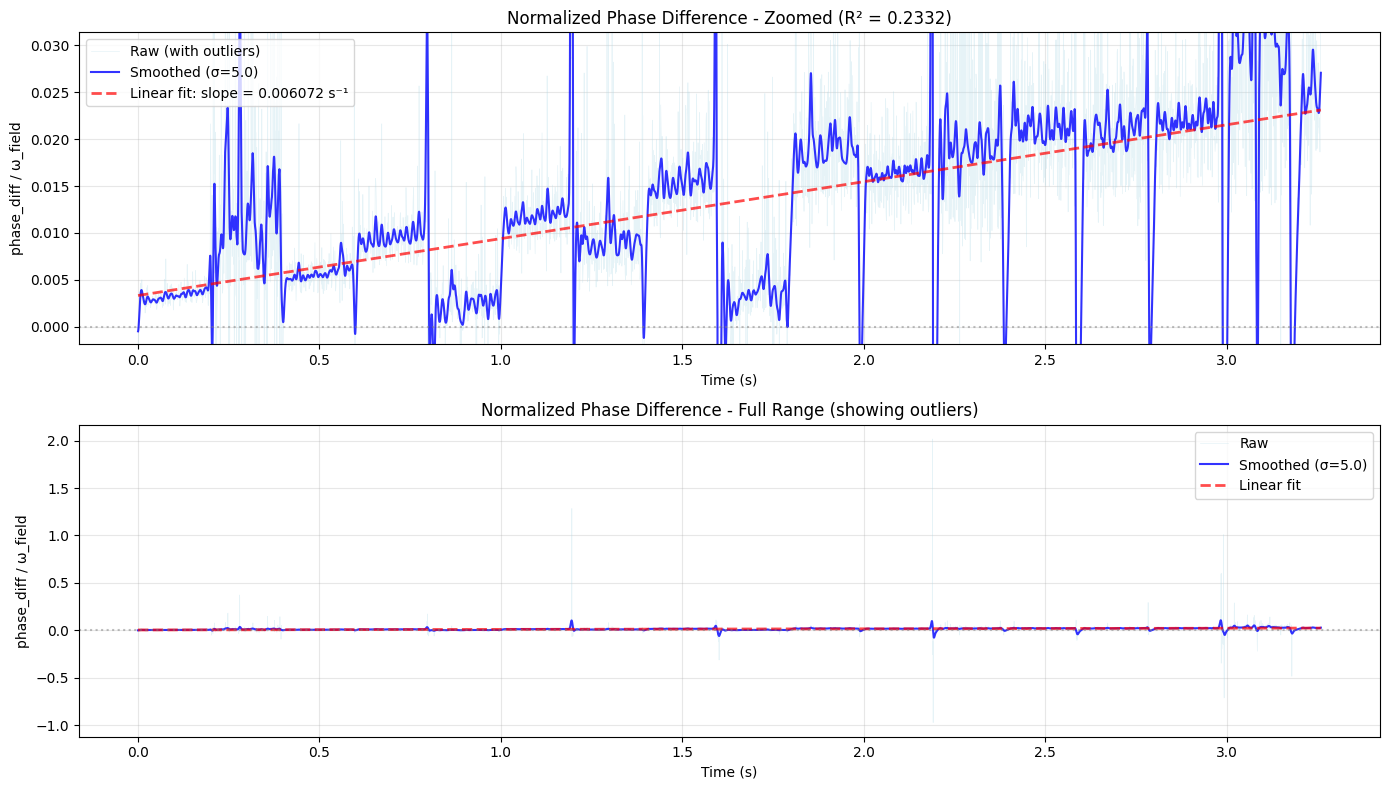

In [9]:
# Visualize normalized phase difference and drift
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Top plot: Phase difference normalized by omega_field (zoomed in, smoothed)
axes[0].plot(t_trim[valid_mask], phase_diff_normalized[valid_mask], linewidth=0.5, alpha=0.3, 
            label='Raw (with outliers)', color='lightblue')
axes[0].plot(t_trim[valid_mask], phase_diff_normalized_smooth[valid_mask], linewidth=1.5, alpha=0.8, 
            label=f'Smoothed (σ={sigma_smooth_norm})', color='blue')
if len(valid_indices) > 0 and not np.isnan(slope_norm):
    fit_line_norm = intercept_norm + slope_norm * t_trim[valid_indices]
    axes[0].plot(t_trim[valid_indices], fit_line_norm, 'r--', linewidth=2, alpha=0.7, 
                label=f'Linear fit: slope = {slope_norm:.6f} s⁻¹')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('phase_diff / ω_field')
axes[0].set_title(f'Normalized Phase Difference - Zoomed (R² = {r_norm**2:.4f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='gray', linestyle=':', alpha=0.5)

# Zoom in: use percentiles to exclude extreme outliers
if len(valid_indices) > 0:
    y_values = phase_diff_normalized_smooth[valid_indices]
    y_p5 = np.nanpercentile(y_values, 5)
    y_p95 = np.nanpercentile(y_values, 95)
    y_range = y_p95 - y_p5
    y_margin = y_range * 0.1  # 10% margin
    axes[0].set_ylim(y_p5 - y_margin, y_p95 + y_margin)

# Bottom plot: Full range view (to see outliers)
axes[1].plot(t_trim[valid_mask], phase_diff_normalized[valid_mask], linewidth=0.5, alpha=0.3, 
            label='Raw', color='lightblue')
axes[1].plot(t_trim[valid_mask], phase_diff_normalized_smooth[valid_mask], linewidth=1.5, alpha=0.8, 
            label=f'Smoothed (σ={sigma_smooth_norm})', color='blue')
if len(valid_indices) > 0 and not np.isnan(slope_norm):
    fit_line_norm = intercept_norm + slope_norm * t_trim[valid_indices]
    axes[1].plot(t_trim[valid_indices], fit_line_norm, 'r--', linewidth=2, alpha=0.7, 
                label=f'Linear fit')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('phase_diff / ω_field')
axes[1].set_title('Normalized Phase Difference - Full Range (showing outliers)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

In [10]:
# Step-by-step drift analysis
print("\n" + "="*70)
print("DRIFT ANALYSIS - STEP BY STEP")
print("="*70)

# Step 1: Naive absolute drift
print(f"\n1. NAIVE ABSOLUTE DRIFT:")
print(f"   Phase difference slope: {slope_phase:.6f} rad/s")
print(f"   R²: {r_phase**2:.4f}")
print(f"   Clock rate error: {clock_rate_error*100:.6f}%")
correction_factor_naive = 1 - clock_rate_error
print(f"   Correction factor: {correction_factor_naive:.8f}")

# Step 2: Normalized phase drift
if len(valid_indices) > 0 and not np.isnan(slope_norm):
    print(f"\n2. NORMALIZED PHASE DRIFT:")
    print(f"   Normalized ratio slope: {slope_norm:.6f} s⁻¹")
    print(f"   R²: {r_norm**2:.4f}")
    print(f"   Interpretation: phase_diff/omega_field changes by {slope_norm:.6f} per second")
    
    # Step 3: Omega drift fit
    mean_omega = np.mean(omega_field_trim[valid_indices])
    
    # Fit linear trend directly to omega_field (naive approach)
    slope_omega_naive, intercept_omega_naive, r_omega_naive, _, _ = linregress(
        t_trim[valid_indices], omega_field_trim[valid_indices])
    slope_omega_norm_naive = slope_omega_naive / mean_omega if abs(mean_omega) > 1e-3 else np.nan
    
    print(f"\n3. OMEGA DRIFT FIT:")
    print(f"   Mean omega_field: {mean_omega:.4f} rad/s")
    print(f"   Omega_field linear fit slope: {slope_omega_naive:.6f} rad/s per second")
    print(f"   Normalized omega drift: {slope_omega_norm_naive:.6f} s⁻¹")
    print(f"   R²: {r_omega_naive**2:.4f}")
    
    print(f"\n" + "-"*70)
    print(f"Summary:")
    print(f"  Absolute phase drift: {slope_phase:.6f} rad/s")
    print(f"  Normalized phase drift: {slope_norm:.6f} s⁻¹")
    print(f"  Normalized omega drift: {slope_omega_norm_naive:.6f} s⁻¹")
else:
    print("\n⚠ Cannot compute normalized drift - insufficient valid data")


DRIFT ANALYSIS - STEP BY STEP

1. NAIVE ABSOLUTE DRIFT:
   Phase difference slope: 1.030183 rad/s
   R²: 0.0612
   Clock rate error: 0.433305%
   Correction factor: 0.99566695

2. NORMALIZED PHASE DRIFT:
   Normalized ratio slope: 0.006072 s⁻¹
   R²: 0.2332
   Interpretation: phase_diff/omega_field changes by 0.006072 per second

3. OMEGA DRIFT FIT:
   Mean omega_field: 19.3136 rad/s
   Omega_field linear fit slope: 20.905633 rad/s per second
   Normalized omega drift: 1.082431 s⁻¹
   R²: 0.0050

----------------------------------------------------------------------
Summary:
  Absolute phase drift: 1.030183 rad/s
  Normalized phase drift: 0.006072 s⁻¹
  Normalized omega drift: 1.082431 s⁻¹


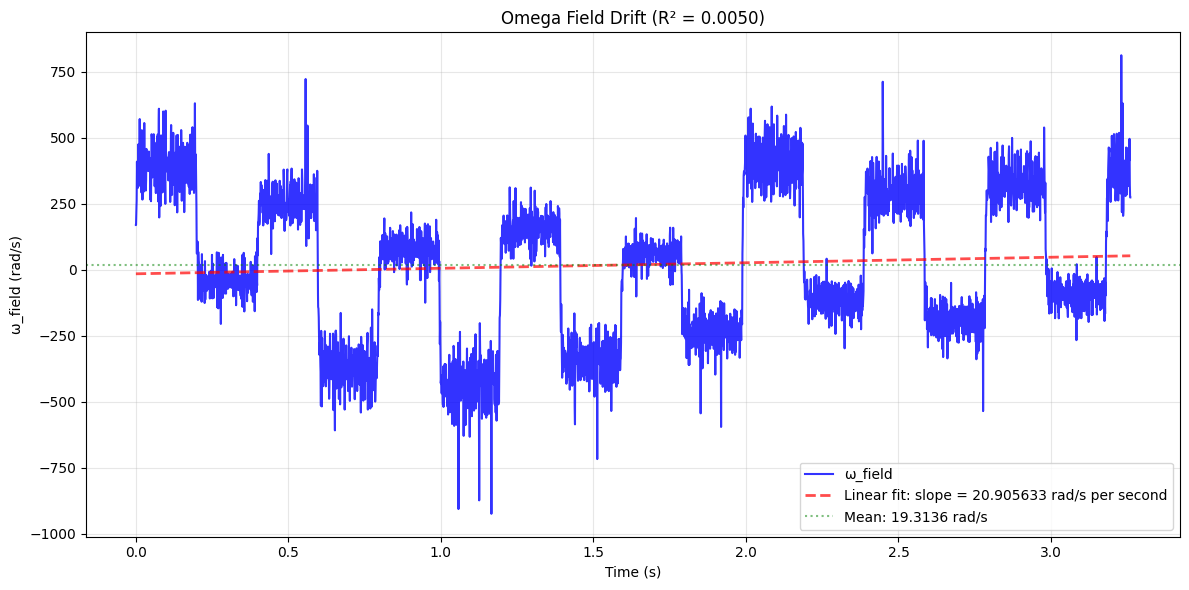

In [11]:
# Plot omega drift
if len(valid_indices) > 0 and not np.isnan(slope_omega_naive):
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    
    # Plot omega_field over time with linear fit
    fit_line_omega = intercept_omega_naive + slope_omega_naive * t_trim[valid_indices]
    ax.plot(t_trim[valid_indices], omega_field_trim[valid_indices], linewidth=1.5, alpha=0.8, 
            label='ω_field', color='blue')
    ax.plot(t_trim[valid_indices], fit_line_omega, 'r--', linewidth=2, alpha=0.7, 
            label=f'Linear fit: slope = {slope_omega_naive:.6f} rad/s per second')
    ax.axhline(y=mean_omega, color='green', linestyle=':', alpha=0.5, 
               label=f'Mean: {mean_omega:.4f} rad/s')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('ω_field (rad/s)')
    ax.set_title(f'Omega Field Drift (R² = {r_omega_naive**2:.4f})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠ Cannot plot omega drift - insufficient valid data")

## Apply Clock Drift Correction

Apply the naive correction factor to the field data and verify the improvement.

In [12]:
# Apply naive correction and analyze phase difference after correction
print("="*70)
print("ANALYZING PHASE DIFFERENCE AFTER NAIVE CORRECTION")
print("="*70)

if len(valid_indices) > 0 and not np.isnan(slope_norm):
    # Apply naive correction to field data
    t_field_naive_corrected = t_trim / correction_factor_naive
    interp_field_naive = interp1d(t_field_naive_corrected, theta_field_trim, 
                                   kind='linear', bounds_error=False, fill_value='extrapolate')
    theta_field_naive_corrected = interp_field_naive(t_trim)
    
    # Also correct omega_field
    interp_omega_naive = interp1d(t_field_naive_corrected, omega_field_trim,
                                  kind='linear', bounds_error=False, fill_value='extrapolate')
    omega_field_naive_corrected = interp_omega_naive(t_trim)
    
    # Compute phase difference after correction
    phase_diff_naive_corrected = theta_field_naive_corrected - theta_trk_trim
    
    # Fit linear trend to phase difference after correction
    slope_phase_naive_corrected, intercept_phase_naive_corrected, r_phase_naive_corrected, _, _ = linregress(
        t_trim, phase_diff_naive_corrected)
    
    print(f"\nPhase difference after naive correction:")
    print(f"  Slope: {slope_phase_naive_corrected:.6f} rad/s")
    print(f"  R²: {r_phase_naive_corrected**2:.4f}")
    print(f"  Original slope (before correction): {slope_phase:.6f} rad/s")
    print(f"  Reduction: {abs(slope_phase - slope_phase_naive_corrected):.6f} rad/s")
    print(f"  Reduction percentage: {abs(slope_phase - slope_phase_naive_corrected)/abs(slope_phase)*100:.2f}%")
    
    # Compute normalized phase difference after correction
    omega_threshold = 1e-3
    valid_mask_naive = np.abs(omega_field_naive_corrected) > omega_threshold
    
    phase_diff_normalized_naive_corrected = np.zeros_like(phase_diff_naive_corrected)
    phase_diff_normalized_naive_corrected[valid_mask_naive] = (
        phase_diff_naive_corrected[valid_mask_naive] / omega_field_naive_corrected[valid_mask_naive]
    )
    phase_diff_normalized_naive_corrected[~valid_mask_naive] = np.nan
    
    # Smooth the normalized phase difference
    from scipy.ndimage import gaussian_filter1d
    sigma_smooth = 5.0
    phase_diff_normalized_naive_corrected_smooth = phase_diff_normalized_naive_corrected.copy()
    phase_diff_normalized_naive_corrected_smooth[valid_mask_naive] = gaussian_filter1d(
        phase_diff_normalized_naive_corrected[valid_mask_naive], sigma=sigma_smooth)
    
    # Fit linear trend to normalized phase difference after correction
    valid_indices_naive = np.where(valid_mask_naive)[0]
    if len(valid_indices_naive) > 0:
        slope_norm_naive_corrected, intercept_norm_naive_corrected, r_norm_naive_corrected, _, _ = linregress(
            t_trim[valid_indices_naive], phase_diff_normalized_naive_corrected_smooth[valid_indices_naive])
        
        print(f"\nNormalized phase difference after naive correction:")
        print(f"  Slope: {slope_norm_naive_corrected:.6f} s⁻¹")
        print(f"  R²: {r_norm_naive_corrected**2:.4f}")
        print(f"  Original normalized slope (before correction): {slope_norm:.6f} s⁻¹")
        print(f"  Change: {slope_norm_naive_corrected - slope_norm:.6f} s⁻¹")
        
        # Also check omega_field drift after correction
        mean_omega_naive_corrected = np.mean(omega_field_naive_corrected[valid_indices_naive])
        slope_omega_naive_corrected, intercept_omega_naive_corrected, r_omega_naive_corrected, _, _ = linregress(
            t_trim[valid_indices_naive], omega_field_naive_corrected[valid_indices_naive])
        slope_omega_norm_naive_corrected = slope_omega_naive_corrected / mean_omega_naive_corrected if abs(mean_omega_naive_corrected) > 1e-3 else np.nan
        
        print(f"\nOmega field drift after naive correction:")
        print(f"  Mean omega: {mean_omega_naive_corrected:.4f} rad/s")
        print(f"  Omega slope: {slope_omega_naive_corrected:.6f} rad/s per second")
        print(f"  Normalized omega slope: {slope_omega_norm_naive_corrected:.6f} s⁻¹")
        print(f"  R²: {r_omega_naive_corrected**2:.4f}")
        print(f"  Original normalized omega slope (before correction): {slope_omega_norm_naive:.6f} s⁻¹")
        
        print(f"\n" + "="*70)
        print("SUMMARY:")
        print("="*70)
        print(f"After naive correction:")
        print(f"  Absolute phase drift: {slope_phase_naive_corrected:.6f} rad/s (was {slope_phase:.6f})")
        print(f"  Normalized phase drift: {slope_norm_naive_corrected:.6f} s⁻¹ (was {slope_norm:.6f})")
        print(f"  Normalized omega drift: {slope_omega_norm_naive_corrected:.6f} s⁻¹ (was {slope_omega_norm_naive:.6f})")
        
        # Plot the normalized phase difference before and after correction
        fig = go.Figure()
        
        # Before correction
        fig.add_trace(go.Scatter(
            x=t_trim[valid_indices], 
            y=phase_diff_normalized_smooth[valid_indices],
            mode='lines', name='Before correction',
            line=dict(color='blue', width=1.5), opacity=0.8
        ))
        
        # After correction
        fig.add_trace(go.Scatter(
            x=t_trim[valid_indices_naive],
            y=phase_diff_normalized_naive_corrected_smooth[valid_indices_naive],
            mode='lines', name='After naive correction',
            line=dict(color='orange', width=1.5), opacity=0.8
        ))
        
        # Fit lines
        fit_before = intercept_norm + slope_norm * t_trim[valid_indices]
        fit_after = intercept_norm_naive_corrected + slope_norm_naive_corrected * t_trim[valid_indices_naive]
        
        fig.add_trace(go.Scatter(
            x=t_trim[valid_indices],
            y=fit_before,
            mode='lines', name=f'Fit before (slope={slope_norm:.6f})',
            line=dict(color='blue', width=2, dash='dash'), opacity=0.7
        ))
        
        fig.add_trace(go.Scatter(
            x=t_trim[valid_indices_naive],
            y=fit_after,
            mode='lines', name=f'Fit after (slope={slope_norm_naive_corrected:.6f})',
            line=dict(color='orange', width=2, dash='dash'), opacity=0.7
        ))
        
        fig.update_xaxes(title_text="Time (s)")
        fig.update_yaxes(title_text="phase_diff / ω_field")
        fig.update_layout(
            title="Normalized Phase Difference: Before vs After Naive Correction",
            height=500,
            hovermode='x unified',
            legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
        )
        
        fig.show()
    else:
        print("⚠ Cannot compute normalized drift - insufficient valid data")
else:
    print("⚠ Cannot analyze - insufficient valid data")

ANALYZING PHASE DIFFERENCE AFTER NAIVE CORRECTION

Phase difference after naive correction:
  Slope: 0.446257 rad/s
  R²: 0.0469
  Original slope (before correction): 1.030183 rad/s
  Reduction: 0.583926 rad/s
  Reduction percentage: 56.68%

Normalized phase difference after naive correction:
  Slope: -0.000672 s⁻¹
  R²: 0.0004
  Original normalized slope (before correction): 0.006072 s⁻¹
  Change: -0.006745 s⁻¹

Omega field drift after naive correction:
  Mean omega: 17.4823 rad/s
  Omega slope: 17.921955 rad/s per second
  Normalized omega slope: 1.025149 s⁻¹
  R²: 0.0038
  Original normalized omega slope (before correction): 1.082431 s⁻¹

SUMMARY:
After naive correction:
  Absolute phase drift: 0.446257 rad/s (was 1.030183)
  Normalized phase drift: -0.000672 s⁻¹ (was 0.006072)
  Normalized omega drift: 1.025149 s⁻¹ (was 1.082431)


## Compute Friction Force

Compute friction force from torque balance: `frc = torque - J * alpha`

Compare corrected vs uncorrected field data.

In [13]:
# Physical parameters for force computation
J_INITIAL = 9.33e-12  # Moment of inertia (kg⋅m²)
B_MAGNET_INITIAL = 0.00113  # Magnetic moment (A⋅m²)

print("="*70)
print("FRICTION FORCE COMPUTATION")
print("="*70)
print(f"\nPhysical parameters:")
print(f"  J (moment of inertia): {J_INITIAL:.2e} kg⋅m²")
print(f"  B (magnetic moment): {B_MAGNET_INITIAL:.2e} A⋅m²")

# Convert magnetic field from mT to T
B_ext = mag_field_trim * 1e-3
B_const = B_MAGNET_INITIAL * B_ext

# Compute magnetic torque: τ = B × B_ext × sin(θ_field - θ_trk)
# Using uncorrected field data
torque_uncorrected = B_const * np.sin(theta_field_trim - theta_trk_trim)
frc_uncorrected = torque_uncorrected - J_INITIAL * alpha_trk_trim

# Check if corrected field data exists (from cell 22)
# theta_field_naive_corrected is created in cell 22 if correction was applied
try:
    # Try to access the corrected theta variable
    theta_corrected = theta_field_naive_corrected
    # Verify it has correct length
    if len(theta_corrected) != len(theta_trk_trim):
        theta_corrected = None
except NameError:
    # Variable doesn't exist - correction hasn't been applied yet
    theta_corrected = None

# Use corrected data if available
if theta_corrected is not None:
    torque_corrected = B_const * np.sin(theta_corrected - theta_trk_trim)
    frc_corrected = torque_corrected - J_INITIAL * alpha_trk_trim
    
    print(f"\nUncorrected data:")
    print(f"  Torque range: [{np.min(torque_uncorrected):.6e}, {np.max(torque_uncorrected):.6e}] N⋅m")
    print(f"  Friction range: [{np.min(frc_uncorrected):.6e}, {np.max(frc_uncorrected):.6e}] N⋅m")
    print(f"  Torque std: {np.std(torque_uncorrected):.6e} N⋅m")
    print(f"  Friction std: {np.std(frc_uncorrected):.6e} N⋅m")
    
    print(f"\nCorrected data:")
    print(f"  Torque range: [{np.min(torque_corrected):.6e}, {np.max(torque_corrected):.6e}] N⋅m")
    print(f"  Friction range: [{np.min(frc_corrected):.6e}, {np.max(frc_corrected):.6e}] N⋅m")
    print(f"  Torque std: {np.std(torque_corrected):.6e} N⋅m")
    print(f"  Friction std: {np.std(frc_corrected):.6e} N⋅m")
    
    print(f"\nDifference:")
    print(f"  Friction std change: {np.std(frc_corrected) - np.std(frc_uncorrected):.6e} N⋅m")
    print(f"  Friction std change %: {(np.std(frc_corrected)/np.std(frc_uncorrected) - 1)*100:.2f}%")
else:
    print("\n⚠ Cannot compute corrected friction - correction not applied yet")
    print("  Run cell 22 first to apply clock drift correction")
    frc_corrected = None
    torque_corrected = None

FRICTION FORCE COMPUTATION

Physical parameters:
  J (moment of inertia): 9.33e-12 kg⋅m²
  B (magnetic moment): 1.13e-03 A⋅m²

Uncorrected data:
  Torque range: [-3.731755e-06, 3.229306e-06] N⋅m
  Friction range: [-4.057241e-06, 4.131702e-06] N⋅m
  Torque std: 1.713628e-06 N⋅m
  Friction std: 1.738735e-06 N⋅m

Corrected data:
  Torque range: [-3.681444e-06, 2.978022e-06] N⋅m
  Friction range: [-3.997857e-06, 3.553497e-06] N⋅m
  Torque std: 1.591045e-06 N⋅m
  Friction std: 1.615149e-06 N⋅m

Difference:
  Friction std change: -1.235858e-07 N⋅m
  Friction std change %: -7.11%


## 3D Visualization: Friction in State Space

Compare friction surfaces for corrected vs uncorrected data using interactive Plotly 3D plots.

In [14]:
# 3D Visualization of Friction in State Space using Plotly
# Create two separate figures for side-by-side comparison

if frc_corrected is not None:
    # Wrap theta to [0, 2π] for visualization
    theta_wrapped = np.mod(theta_trk_trim, 2*np.pi)
    
    # Convert to Cartesian coordinates with radius offset
    omega_offset = omega_trk_trim - np.min(omega_trk_trim)
    xs = omega_offset * np.cos(theta_wrapped)
    ys = omega_offset * np.sin(theta_wrapped)
    
    # Scale friction for visibility
    zs_uncorrected = frc_uncorrected * 1e8
    zs_corrected = frc_corrected * 1e8
    
    # Calculate ranges for equal aspect ratio (use same for both)
    max_range = np.max([xs.max() - xs.min(), ys.max() - ys.min()]) / 2.0
    mid_x = (xs.max() + xs.min()) * 0.5
    mid_y = (ys.max() + ys.min()) * 0.5
    
    scene_layout = dict(
        xaxis=dict(title='ω cos(θ)', range=[mid_x - max_range, mid_x + max_range]),
        yaxis=dict(title='ω sin(θ)', range=[mid_y - max_range, mid_y + max_range]),
        zaxis=dict(title='Force × 10⁸ (N⋅m)'),
        aspectmode='manual',
        aspectratio=dict(x=1, y=1, z=0.7),
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.2))
    )
    
    # Uncorrected plot
    fig_uncorrected = go.Figure(data=[go.Scatter3d(
        x=xs,
        y=ys,
        z=zs_uncorrected,
        mode='markers',
        marker=dict(
            size=2,
            color=frc_uncorrected,
            colorscale='Viridis',
            colorbar=dict(title='Friction (N⋅m)', x=1.02, len=0.7),
            showscale=True
        ),
        text=[f'θ={theta_wrapped[i]:.2f} rad<br>ω={omega_trk_trim[i]:.1f} rad/s<br>F={frc_uncorrected[i]:.2e} N⋅m'
              for i in range(len(frc_uncorrected))],
        hovertemplate='<b>Uncorrected</b><br>%{text}<extra></extra>'
    )])
    
    fig_uncorrected.update_layout(
        title=f'Uncorrected Field Data (J={J_INITIAL:.2e}, B={B_MAGNET_INITIAL:.2e})',
        scene=scene_layout,
        width=900,
        height=700
    )
    
    # Corrected plot
    fig_corrected = go.Figure(data=[go.Scatter3d(
        x=xs,
        y=ys,
        z=zs_corrected,
        mode='markers',
        marker=dict(
            size=2,
            color=frc_corrected,
            colorscale='Viridis',
            colorbar=dict(title='Friction (N⋅m)', x=1.02, len=0.7),
            showscale=True
        ),
        text=[f'θ={theta_wrapped[i]:.2f} rad<br>ω={omega_trk_trim[i]:.1f} rad/s<br>F={frc_corrected[i]:.2e} N⋅m'
              for i in range(len(frc_corrected))],
        hovertemplate='<b>Corrected</b><br>%{text}<extra></extra>'
    )])
    
    fig_corrected.update_layout(
        title=f'Corrected Field Data (Clock Drift Removed)',
        scene=scene_layout,
        width=900,
        height=700
    )
    
    # Show both plots
    fig_uncorrected.show()
    fig_corrected.show()
    
    print("\n✓ 3D friction visualization created")
    print("  Drag to rotate, scroll to zoom, hover for values")
    print("  First plot: Uncorrected field data")
    print("  Second plot: Corrected field data (clock drift removed)")
else:
    print("⚠ Cannot create 3D plot - corrected friction not computed")


✓ 3D friction visualization created
  Drag to rotate, scroll to zoom, hover for values
  First plot: Uncorrected field data
  Second plot: Corrected field data (clock drift removed)
